# 📊 Time Series Forecasting + Anomaly Detection

This project builds a machine learning pipeline to:

- Forecast Wikipedia page views using time series data
- Detect anomalies using forecast residuals
- Compare baseline vs improved models

## Techniques Used
- Feature Engineering (Lag, Rolling, Date Features)
- XGBoost Regression
- Residual-based Anomaly Detection (Z-score)

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 📂 Data Loading

We load the Wikipedia web traffic dataset and select one page for analysis.

In [46]:
df = pd.read_csv("E:/datasets/wiki/train_1.csv/train_1.csv")
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [47]:
sample = df.iloc[0]

In [48]:
ts = sample[1:]

## 🔄 Data Preprocessing

- Convert wide format to time series format
- Parse dates
- Handle missing values

In [49]:
ts = ts.reset_index()
ts.columns = ["date", "views"]

In [50]:
ts["date"] = pd.to_datetime(ts["date"])
ts["views"] = pd.to_numeric(ts["views"], errors="coerce")

In [51]:
ts = ts.dropna()
ts = ts.sort_values("date").reset_index(drop=True)

## 📊 Exploratory Data Analysis

We analyze:
- Trend and spikes
- Distribution of values
- Weekly patterns
- Autocorrelation

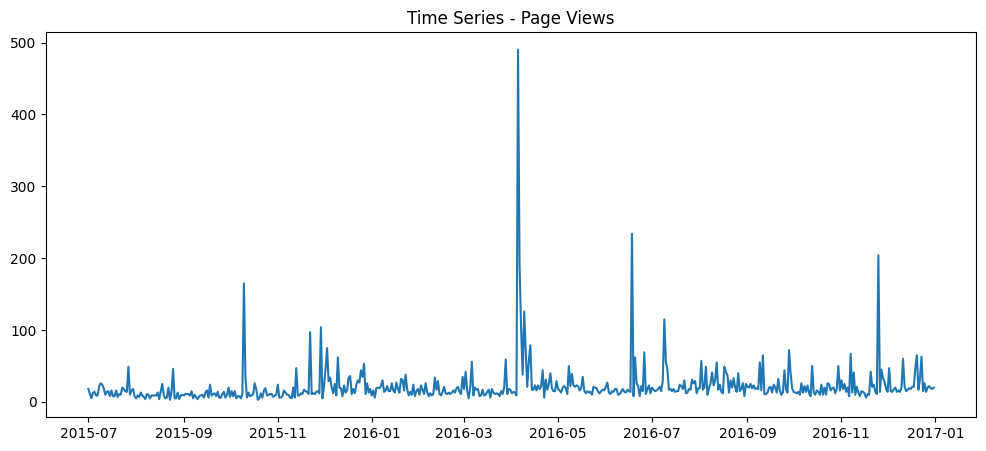

In [52]:
plt.figure(figsize=(12,5))
plt.plot(ts["date"], ts["views"])
plt.title("Time Series - Page Views")
plt.show()

In [53]:
ts.head()

,date,views
0,2015-07-01,18.0
1,2015-07-02,11.0
2,2015-07-03,5.0
3,2015-07-04,13.0
4,2015-07-05,14.0


In [54]:
ts["views"].describe()

count    550.000000
mean      21.756364
std       29.390758
min        3.000000
25%       11.000000
50%       16.000000
75%       22.000000
max      490.000000
Name: views, dtype: float64

In [55]:
ts["day_of_week"] = ts["date"].dt.dayofweek

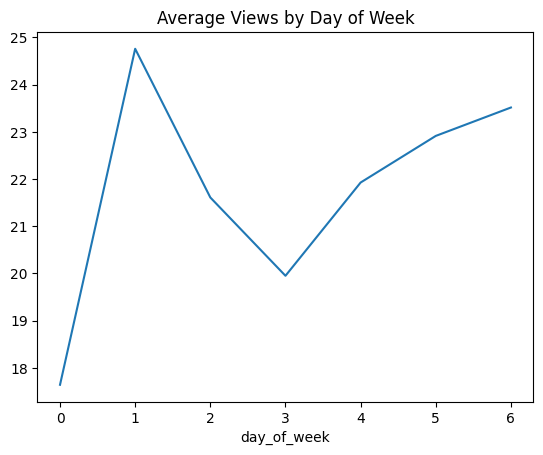

In [56]:
ts.groupby("day_of_week")["views"].mean().plot()
plt.title("Average Views by Day of Week")
plt.show()

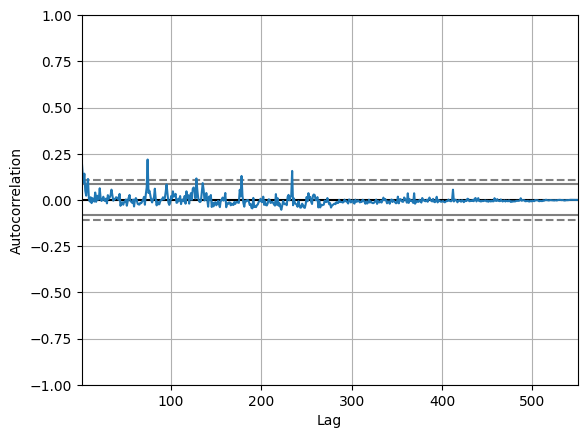

In [57]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(ts["views"])
plt.show()

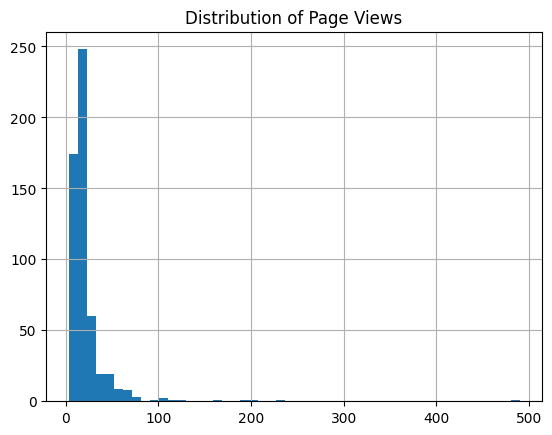

In [58]:
ts["views"].hist(bins=50)
plt.title("Distribution of Page Views")
plt.show()

## ⚙️ Feature Engineering

We create:
- Lag features (past values)
- Rolling statistics
- Calendar features

In [59]:
ts["lag_1"] = ts["views"].shift(1)
ts["lag_7"] = ts["views"].shift(7)
ts["lag_14"] = ts["views"].shift(14)

In [60]:
ts["rolling_mean_7"] = ts["views"].rolling(window=7).mean()
ts["rolling_std_7"] = ts["views"].rolling(window=7).std()

In [61]:
ts["day_of_week"] = ts["date"].dt.dayofweek
ts["month"] = ts["date"].dt.month

In [62]:
ts = ts.dropna().reset_index(drop=True)

In [63]:
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

In [64]:
features = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
    "day_of_week", "month"
]

X_train = train[features]
y_train = train["views"]

X_test = test[features]
y_test = test["views"]

## 🤖 Baseline Model

We train an XGBoost model using basic lag and rolling features.

In [65]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [66]:
preds = model.predict(X_test)

In [67]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)

MAE: 11.184807936350504


## 📈 Forecast Results

Comparison of predicted vs actual values.

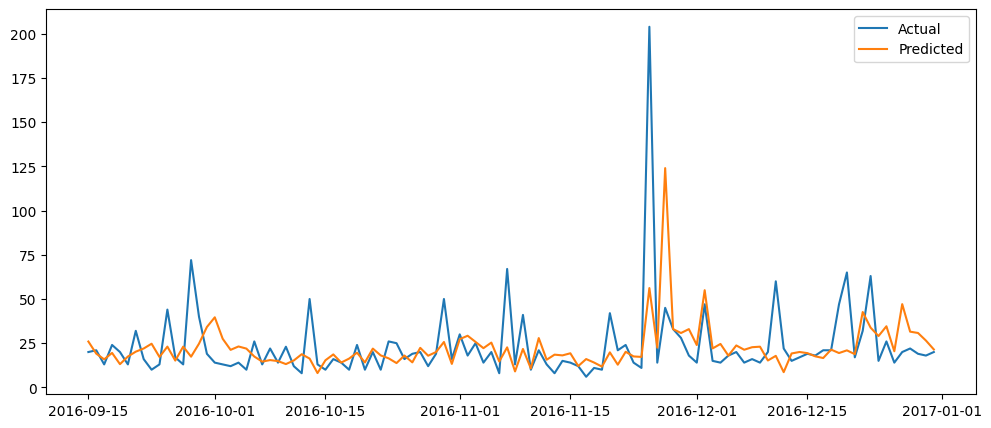

In [68]:
plt.figure(figsize=(12,5))
plt.plot(test["date"], y_test, label="Actual")
plt.plot(test["date"], preds, label="Predicted")
plt.legend()
plt.show()

In [69]:
test = test.copy()
test["preds"] = preds

test["residual"] = test["views"] - test["preds"]

In [70]:
mean = test["residual"].mean()
std = test["residual"].std()

test["z_score"] = (test["residual"] - mean) / std

In [71]:
threshold = 3

test["anomaly"] = test["z_score"].abs() > threshold

In [72]:
test[test["anomaly"] == True][["date", "views", "preds", "residual"]]

,date,views,preds,residual
499,2016-11-25,204.0,56.179306,147.820694
501,2016-11-27,45.0,124.042915,-79.042915


## 🚨 Anomaly Detection (Baseline)

We detect anomalies using residuals and Z-score.

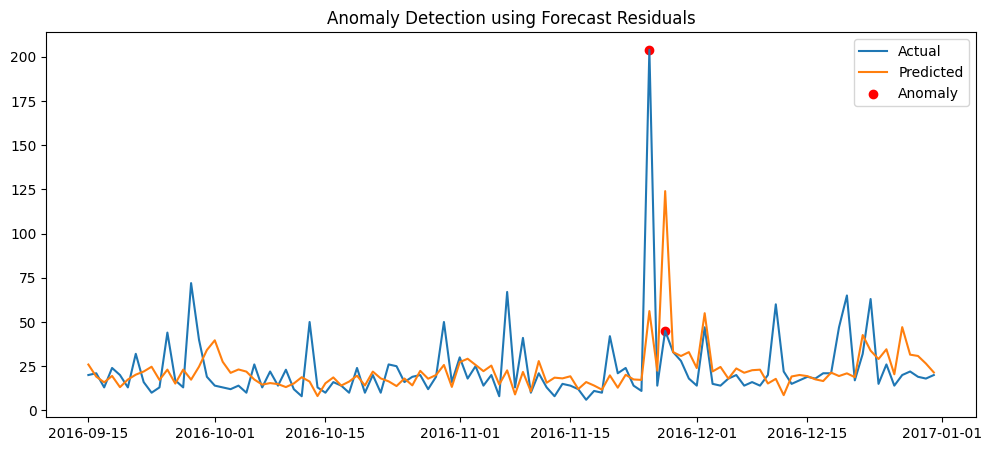

In [73]:
plt.figure(figsize=(12,5))
plt.plot(test["date"], test["views"], label="Actual")
plt.plot(test["date"], test["preds"], label="Predicted")
plt.scatter(
    test["date"][test["anomaly"]],
    test["views"][test["anomaly"]],
    color="red",
    label="Anomaly"
)
plt.legend()
plt.title("Anomaly Detection using Forecast Residuals")
plt.show()

## 🚀 Improved Model

We enhance feature engineering with:
- Additional lags
- Rolling windows
- Difference features

In [74]:
ts_new = ts.copy()
ts_new["lag_2"] = ts_new["views"].shift(2)
ts_new["lag_3"] = ts_new["views"].shift(3)
ts_new["lag_30"] = ts_new["views"].shift(30)

ts_new["rolling_mean_3"] = ts_new["views"].rolling(3).mean()
ts_new["rolling_mean_14"] = ts_new["views"].rolling(14).mean()
ts_new["rolling_max_7"] = ts_new["views"].rolling(7).max()

ts_new["diff_1"] = ts_new["views"] - ts_new["lag_1"]

In [75]:
ts_new = ts_new.dropna().reset_index(drop=True)

In [76]:
train_size_new = int(len(ts_new) * 0.8)

train_new = ts_new[:train_size_new]
test_new = ts_new[train_size_new:]

In [77]:
features_new = [
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_30",
    "rolling_mean_3", "rolling_mean_7", "rolling_mean_14",
    "rolling_std_7", "rolling_max_7",
    "diff_1",
    "day_of_week", "month"
]

In [78]:
from xgboost import XGBRegressor

model_new = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

X_train_new = train_new[features_new]
y_train_new = train_new["views"]

X_test_new = test_new[features_new]
y_test_new = test_new["views"]

model_new.fit(X_train_new, y_train_new)

preds_new = model_new.predict(X_test_new)

## 📊 Model Comparison

We compare baseline vs improved model performance using MAE and visualization.

In [79]:
mae_old = mean_absolute_error(y_test, preds)   # your existing
mae_new = mean_absolute_error(y_test_new, preds_new)

print("Old MAE:", mae_old)
print("New MAE:", mae_new)

Old MAE: 11.184807936350504
New MAE: 2.1666731460421693


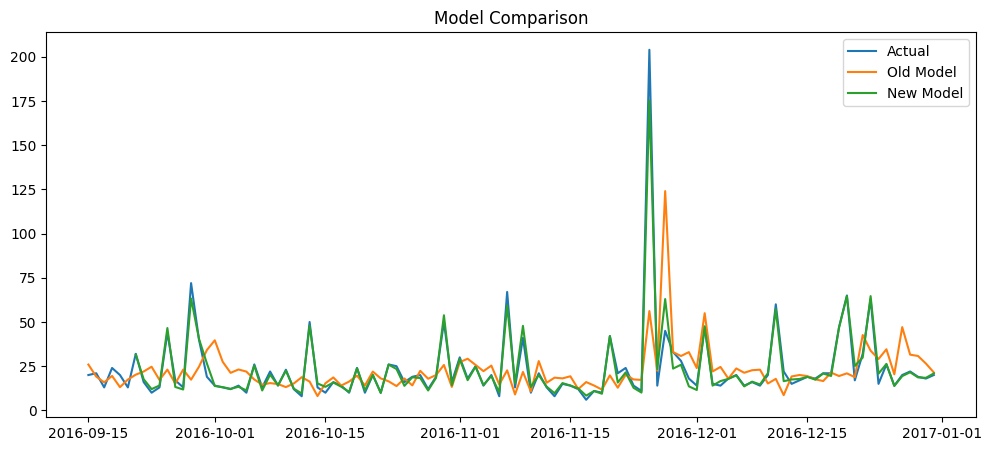

In [80]:
plt.figure(figsize=(12,5))

plt.plot(test["date"], y_test, label="Actual")
plt.plot(test["date"], preds, label="Old Model")
plt.plot(test_new["date"], preds_new, label="New Model")

plt.legend()
plt.title("Model Comparison")
plt.show()

## 🚨 Anomaly Detection (Improved Model)

We apply the same anomaly detection method to the improved model.

In [81]:
test_new = test_new.copy()

test_new["preds"] = preds_new
test_new["residual"] = test_new["views"] - test_new["preds"]

In [82]:
mean_new = test_new["residual"].mean()
std_new = test_new["residual"].std()

test_new["z_score"] = (test_new["residual"] - mean_new) / std_new

In [83]:
threshold = 3

test_new["anomaly"] = test_new["z_score"].abs() > threshold

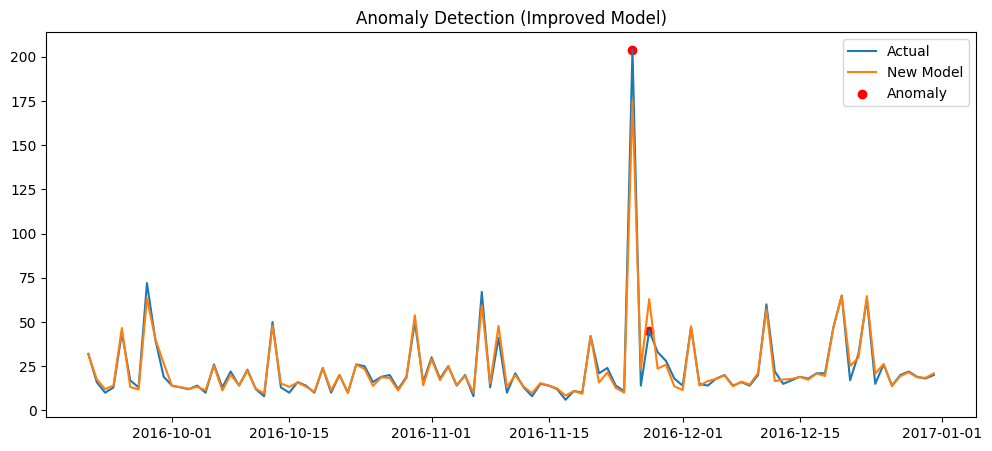

In [84]:
plt.figure(figsize=(12,5))

plt.plot(test_new["date"], test_new["views"], label="Actual")

plt.plot(test_new["date"], test_new["preds"], label="New Model")

plt.scatter(
    test_new["date"][test_new["anomaly"]],
    test_new["views"][test_new["anomaly"]],
    color="red",
    label="Anomaly"
)

plt.legend()
plt.title("Anomaly Detection (Improved Model)")
plt.show()

## 🧠 Key Insights

### 📊 Data Behavior
- The time series is highly noisy with weak autocorrelation
- Sudden spikes are present, indicating irregular traffic patterns

### 🤖 Model Performance
- The baseline model captures general trends but lags behind sudden changes
- The improved model reacts better to short-term variations due to enhanced feature engineering

### 🚨 Anomaly Detection
- Large spikes are successfully detected using residual-based Z-score
- However, false positives occur after extreme spikes due to model overestimation (prediction lag)

### ⚖️ Trade-off Observed
- Improved forecasting accuracy reduces residual magnitude
- This weakens anomaly signals, showing a trade-off between prediction performance and anomaly sensitivity

## 📌 Conclusion

A combination of forecasting + residual analysis provides an effective anomaly detection system.